 
## Goal
- Create issue in team member's repo
- Respond to issue
- Identify how word choice is similar between two texts
  from the same author. In this example I chose The Odyssey
  and Illiad by Homer to research.
## Methods
- Pull the text from Gutenberg Website 
- Limit down text to only have plaintext
- Identify similar word patterns between texts
- Compare words and see which get used in more in
  one of the texts
## Links
- Odyssey: https://www.gutenberg.org/ebooks/1727 (Butler Translation)
- Illiad: https://www.gutenberg.org/ebooks/2199 (Butler Translation) 

In [15]:
import requests, re, nltk
from bs4 import BeautifulSoup
from collections import Counter

nltk.download('stopwords', quiet=True)
stop_words = set(nltk.corpus.stopwords.words('english') + ['', 'said', "'s", "'re", '--', 've'])

def cleanHtml(html):
    return BeautifulSoup(html, 'html.parser').get_text()

def cleanWord(w):
    wn = re.sub('[,"\'&\|:@>*;/=]', "", w)
    return re.sub('^[0-9\.]*$', "", wn)

def get_wf(url):
    r = requests.get(url)
    t = cleanHtml(r.text).lower()
    wds = [cleanWord(w) for w in re.split('\s+', t)]
    wf = Counter(wds)
    for k in stop_words:
        wf.pop(k, None)
    total = sum(wf.values())
    return wf, total

In [16]:
wf_odyssey, total_odyssey = get_wf('https://www.gutenberg.org/ebooks/1727.txt.utf-8')
wf_iliad, total_iliad = get_wf('https://www.gutenberg.org/ebooks/2199.txt.utf-8')

print("Odyssey - total words:", total_odyssey)
print("Odyssey - top 15:", wf_odyssey.most_common(15))
print()
print("Iliad - total words:", total_iliad)
print("Iliad - top 15:", wf_iliad.most_common(15))

Odyssey - total words: 61315
Odyssey - top 15: [('ulysses', 556), ('one', 541), ('would', 380), ('house', 340), ('man', 302), ('went', 300), ('men', 298), ('come', 277), ('us', 273), ('upon', 268), ('may', 264), ('go', 263), ('tell', 261), ('see', 253), ('son', 247)]

Iliad - total words: 73948
Iliad - top 15: [('son', 948), ('upon', 537), ('trojans', 474), ('one', 455), ('achaeans', 452), ('man', 397), ('would', 397), ('hector', 393), ('jove', 388), ('achilles', 374), ('shall', 365), ('ships', 364), ('spear', 345), ('men', 344), ('went', 326)]


In [17]:
wf_aeneid, total_aeneid = get_wf('https://www.gutenberg.org/ebooks/73488.txt.utf-8')

print("Aeneid - total words:", total_aeneid)
print("Aeneid - top 15:", wf_aeneid.most_common(15))

Aeneid - total words: 67934
Aeneid - top 15: [('æneas', 277), ('shall', 231), ('hand', 229), ('first', 219), ('one', 207), ('mighty', 179), ('us', 166), ('father', 159), ('thus', 153), ('let', 152), ('son', 150), ('like', 146), ('gods', 146), ('whole', 144), ('arms', 143)]


In [18]:
extra_stopwords = {'ulysses', 'trojans', 'achaeans', 'hector', 'jove', 'achilles',
                    'æneas', 'aeneas', 'troy', 'ships', 'spear', 'gods', 'son'}

for wf in (wf_odyssey, wf_iliad, wf_aeneid):
    for name in extra_stopwords:
        wf.pop(name, None)

def relative_freq(wf, total):
    return {w: c / total for w, c in wf.items()}

rf_iliad = relative_freq(wf_iliad, total_iliad)
rf_aeneid = relative_freq(wf_aeneid, total_aeneid)

common = set(rf_iliad) & set(rf_aeneid)
diffs = [(w, rf_iliad[w] - rf_aeneid[w]) for w in common
         if wf_iliad[w] >= 15 and wf_aeneid[w] >= 15]
diffs.sort(key=lambda x: x[1])

print("Words Virgil (Aeneid) favors over Homer (Iliad):")
for w, d in diffs[:10]:
    print(f"  {w:10s} Iliad={rf_iliad[w]:.5f}  Aeneid={rf_aeneid[w]:.5f}")

print("\nWords Homer (Iliad) favors over Virgil (Aeneid):")
for w, d in diffs[-10:][::-1]:
    print(f"  {w:10s} Iliad={rf_iliad[w]:.5f}  Aeneid={rf_aeneid[w]:.5f}")

Words Virgil (Aeneid) favors over Homer (Iliad):
  arms       Iliad=0.00045  Aeneid=0.00210
  whole      Iliad=0.00069  Aeneid=0.00212
  name       Iliad=0.00030  Aeneid=0.00159
  last       Iliad=0.00046  Aeneid=0.00169
  first      Iliad=0.00203  Aeneid=0.00322
  mighty     Iliad=0.00153  Aeneid=0.00263
  war        Iliad=0.00072  Aeneid=0.00181
  along      Iliad=0.00047  Aeneid=0.00155
  deep       Iliad=0.00047  Aeneid=0.00149
  walls      Iliad=0.00032  Aeneid=0.00132

Words Homer (Iliad) favors over Virgil (Aeneid):
  upon       Iliad=0.00726  Aeneid=0.00094
  went       Iliad=0.00441  Aeneid=0.00022
  man        Iliad=0.00537  Aeneid=0.00155
  would      Iliad=0.00537  Aeneid=0.00171
  fight      Iliad=0.00407  Aeneid=0.00052
  one        Iliad=0.00615  Aeneid=0.00305
  men        Iliad=0.00465  Aeneid=0.00160
  horses     Iliad=0.00330  Aeneid=0.00032
  go         Iliad=0.00365  Aeneid=0.00078
  came       Iliad=0.00364  Aeneid=0.00085


In [19]:
rf_odyssey = relative_freq(wf_odyssey, total_odyssey)

common2 = set(rf_odyssey) & set(rf_iliad)
diffs2 = [(w, rf_odyssey[w] - rf_iliad[w]) for w in common2
          if wf_odyssey[w] >= 15 and wf_iliad[w] >= 15]
diffs2.sort(key=lambda x: x[1])

print("Words Iliad favors over Odyssey (same author):")
for w, d in diffs2[:10]:
    print(f"  {w:10s} Odyssey={rf_odyssey[w]:.5f}  Iliad={rf_iliad[w]:.5f}")

print("\nWords Odyssey favors over Iliad (same author):")
for w, d in diffs2[-10:][::-1]:
    print(f"  {w:10s} Odyssey={rf_odyssey[w]:.5f}  Iliad={rf_iliad[w]:.5f}")

Words Iliad favors over Odyssey (same author):
  fight      Odyssey=0.00044  Iliad=0.00407
  upon       Odyssey=0.00437  Iliad=0.00726
  horses     Odyssey=0.00046  Iliad=0.00330
  armour     Odyssey=0.00046  Iliad=0.00260
  thus       Odyssey=0.00188  Iliad=0.00400
  body       Odyssey=0.00055  Iliad=0.00254
  agamemnon  Odyssey=0.00046  Iliad=0.00243
  struck     Odyssey=0.00038  Iliad=0.00206
  hand       Odyssey=0.00142  Iliad=0.00310
  chariot    Odyssey=0.00024  Iliad=0.00184

Words Odyssey favors over Iliad (same author):
  house      Odyssey=0.00555  Iliad=0.00174
  tell       Odyssey=0.00426  Iliad=0.00120
  one        Odyssey=0.00882  Iliad=0.00615
  ship       Odyssey=0.00326  Iliad=0.00065
  home       Odyssey=0.00325  Iliad=0.00101
  got        Odyssey=0.00292  Iliad=0.00069
  good       Odyssey=0.00329  Iliad=0.00134
  see        Odyssey=0.00413  Iliad=0.00224
  get        Odyssey=0.00241  Iliad=0.00070
  much       Odyssey=0.00331  Iliad=0.00164


In [20]:
import matplotlib.pyplot as plt

def plotTwoLists(list1, list2, title, label1='Book 1', label2='Book 2'):
    words1, counts1 = zip(*list1)
    words2, counts2 = zip(*list2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].barh(words1, counts1, color='steelblue')
    axes[0].set_title(label1)
    axes[1].barh(words2, counts2, color='indianred')
    axes[1].set_title(label2)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

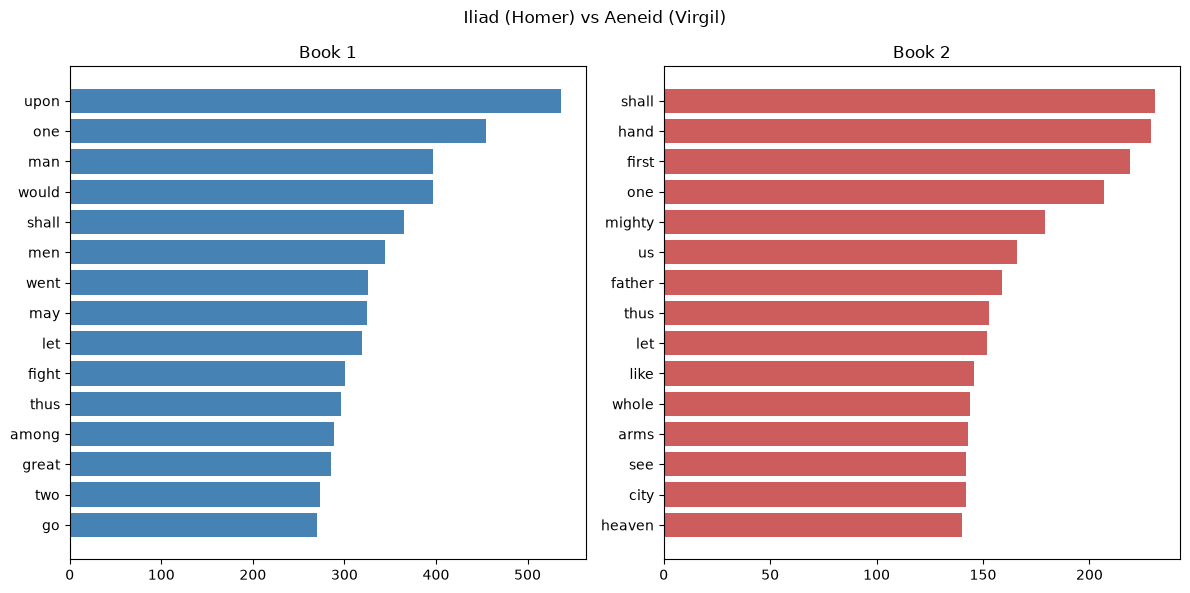

In [21]:
plotTwoLists(wf_iliad.most_common(15)[::-1], wf_aeneid.most_common(15)[::-1],
             'Iliad (Homer) vs Aeneid (Virgil)')

## Conclusion


The *Iliad* and *Odyssey* use different words because they focus on different topics. The *Iliad* is mostly about war, while the *Odyssey* is mostly about travel and returning home. Even if both are by the same author, there is an apparent difference in what words are most commonly used. 

This shows that word choice can depend on the topic, not just the author. Some words appeared often in both works, which may show Homer's writing style. However, these words could also come from the translator. The books all have similar topics, but authors tend to add their own creative liberty to their works. 

A final limitation is that the *Aeneid* had a different translator, so some of the differences may be caused by translation rather than by Homer and Virgil themselves. There is no definitive way to know for sure if what is translated is correct due to the age of these stories. The different translation also plays a role in this flaw.

